# Predicting Insurance Claim Amounts

**Objective:** estimate how much a person's medical insurance charges will be, based on personal details like age, BMI, smoking status, and number of children.

**Dataset:** Medical Cost Personal Dataset, 1,338 records with 7 columns. The target column is `charges`, which is the annual medical insurance cost billed to the customer.

This notebook loads and explores the data, visualizes how each feature relates to insurance charges, trains a Linear Regression model to predict charges, and evaluates how well it performs using MAE and RMSE.

In [1]:
# importing all the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

## Loading the data

In [2]:
df = pd.read_csv('insurance_data.csv')

# shape tells us how many rows and columns there are
print('Rows and columns:', df.shape)
df.head()

Rows and columns: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# quick summary of each column: data type, non-null count
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
# basic statistics for numeric columns
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Checking for missing values

Before doing anything else, we check whether any values are missing. Missing data needs to be handled before training a model.

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No missing values in this dataset, so we can move straight to exploring it.

## Exploratory data analysis

The goal here is to understand which features seem to have a strong relationship with insurance charges before we build the model.

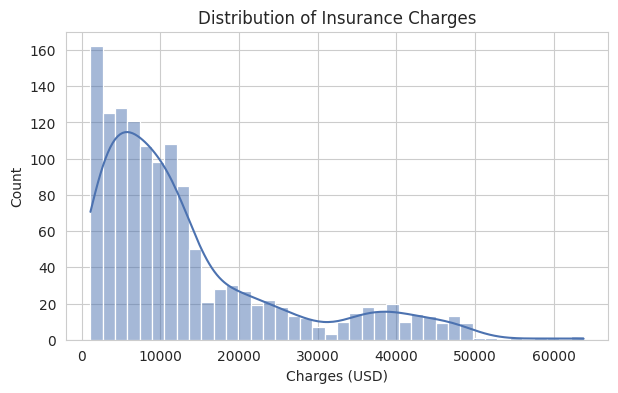

In [6]:
# distribution of insurance charges
plt.figure(figsize=(7, 4))
sns.histplot(df['charges'], bins=40, kde=True, color='#4C72B0')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges (USD)')
plt.show()

Charges are right-skewed, most people have relatively low costs but a smaller group has very high charges. This is common with medical costs.

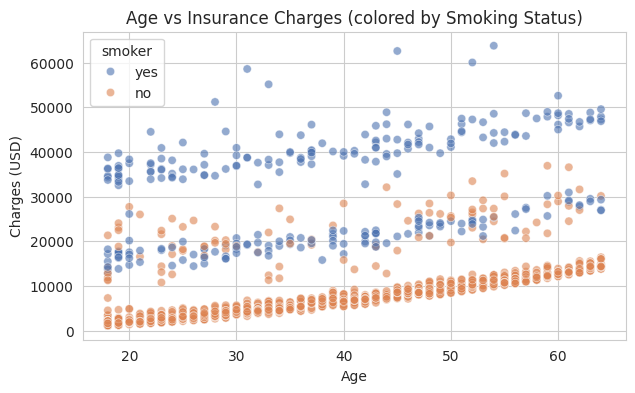

In [7]:
# how does age relate to charges?
plt.figure(figsize=(7, 4))
sns.scatterplot(x='age', y='charges', data=df, hue='smoker', palette=['#4C72B0', '#DD8452'], alpha=0.6)
plt.title('Age vs Insurance Charges (colored by Smoking Status)')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.show()

There are clearly two bands in this chart. Smokers (orange) sit in a much higher cost band than non-smokers (blue) at every age. Within each band, charges do rise with age, but smoking status creates a much bigger jump than age alone.

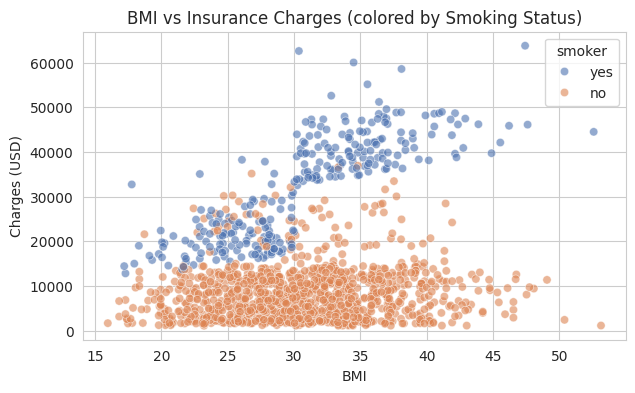

In [8]:
# how does BMI relate to charges?
plt.figure(figsize=(7, 4))
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker', palette=['#4C72B0', '#DD8452'], alpha=0.6)
plt.title('BMI vs Insurance Charges (colored by Smoking Status)')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.show()

For non-smokers, BMI has very little visible effect on charges. For smokers, higher BMI pushes costs noticeably higher, suggesting the combination of smoking and high BMI is particularly costly.

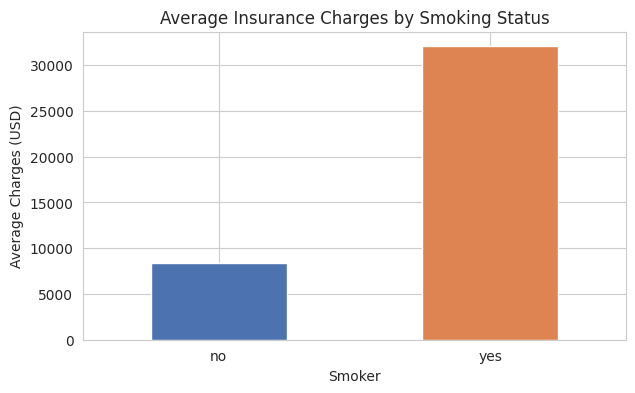

smoker
no      8434.27
yes    32050.23
Name: charges, dtype: float64


In [9]:
# average charges by smoking status
avg_by_smoker = df.groupby('smoker')['charges'].mean()
avg_by_smoker.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Average Insurance Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Average Charges (USD)')
plt.xticks(rotation=0)
plt.show()

print(avg_by_smoker.round(2))

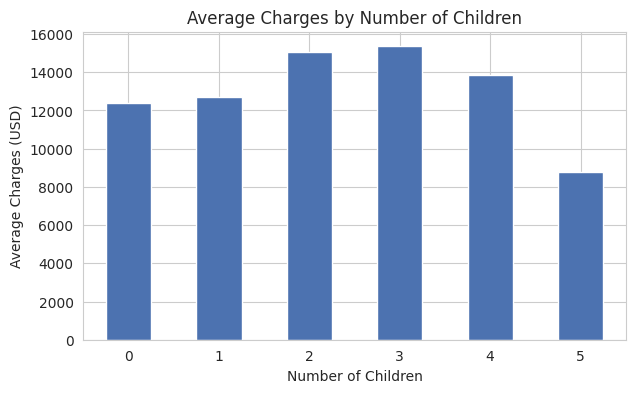

In [10]:
# average charges by number of children
avg_by_children = df.groupby('children')['charges'].mean()
avg_by_children.plot(kind='bar', color='#4C72B0')
plt.title('Average Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Average Charges (USD)')
plt.xticks(rotation=0)
plt.show()

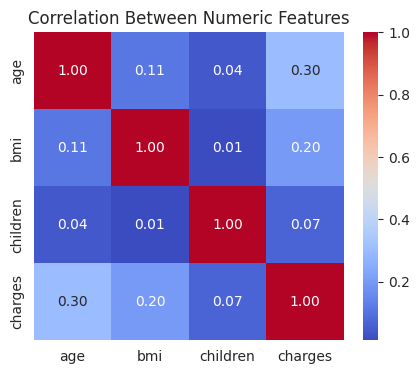

In [11]:
# correlation heatmap for numeric columns only
numeric_cols = ['age', 'bmi', 'children', 'charges']
plt.figure(figsize=(5, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Between Numeric Features')
plt.show()

Age has the strongest correlation with charges among the numeric features (0.30), but it is still relatively modest, which suggests the categorical features like smoking status carry more of the predictive weight.

## Preparing the data for modeling

Machine learning models only work with numbers, so the text columns need to be converted first.

`sex` and `smoker` each have two categories so label encoding works fine here. `region` has four categories so it gets one-hot encoded, which creates a separate yes/no column for each region instead of assigning arbitrary numbers.

In [12]:
# make a copy so the original stays intact
model_df = df.copy()

# label encode sex and smoker
le = LabelEncoder()
model_df['sex'] = le.fit_transform(model_df['sex'])      # female=0, male=1
model_df['smoker'] = le.fit_transform(model_df['smoker'])  # no=0, yes=1

# one-hot encode region
model_df = pd.get_dummies(model_df, columns=['region'], drop_first=True)

model_df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


## Splitting the data

We split the data into a training set (80%) and a test set (20%). The model learns from the training set and is evaluated on the test set, which it has never seen before. This gives us an honest picture of how well it would perform on new data.

In [13]:
X = model_df.drop('charges', axis=1)  # everything except the target
y = model_df['charges']               # what we are trying to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

Training rows: 1070
Test rows: 268


## Training the Linear Regression model

Linear Regression works by finding the best straight-line relationship between the input features and the target. It figures out how much each feature (age, BMI, smoker status, etc.) contributes to the predicted charge, and combines them into a single prediction.

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


## Evaluating the model

In [15]:
pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2   = model.score(X_test, y_test)

print(f'MAE  (Mean Absolute Error):       ${mae:,.2f}')
print(f'RMSE (Root Mean Squared Error):   ${rmse:,.2f}')
print(f'R² Score:                          {r2:.3f}')

MAE  (Mean Absolute Error):       $4,181.19
RMSE (Root Mean Squared Error):   $5,796.28
R² Score:                          0.784


**MAE** tells us that on average the model's predictions are off by about $4,181. In plain terms, if someone's actual charge is $10,000, the model might predict anywhere from roughly $5,800 to $14,200.

**RMSE** is higher than MAE because it penalizes large errors more. The gap between them suggests the model makes a few predictions that are quite far off, likely for high-cost cases like heavy smokers with high BMI.

**R² of 0.784** means the model explains about 78% of the variation in insurance charges, which is a reasonable result for a simple linear regression with no feature engineering.

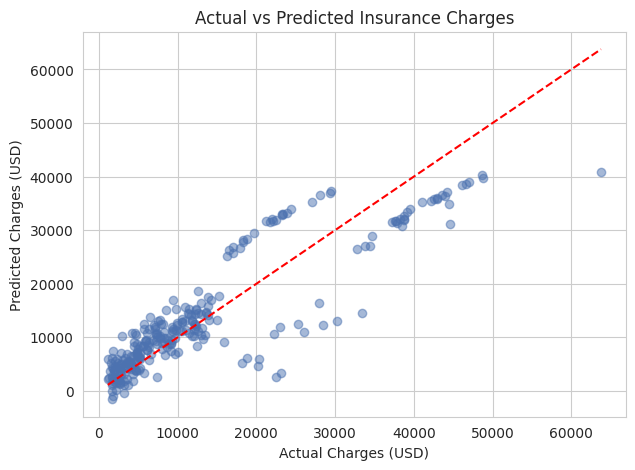

In [16]:
# plot actual vs predicted charges
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred, alpha=0.5, color='#4C72B0')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.title('Actual vs Predicted Insurance Charges')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.show()

Points sitting on the red dashed line are perfect predictions. Points far above or below it are errors. The model does well in the lower charge range but tends to underpredict the highest-cost cases.

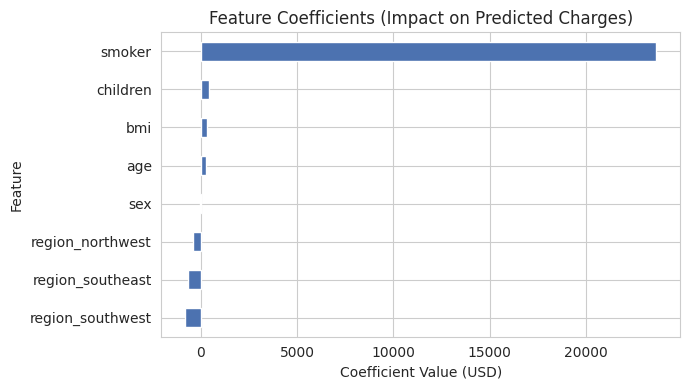

In [17]:
# what does each feature contribute to the prediction?
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=True)

coef_df.plot(kind='barh', x='Feature', y='Coefficient', color='#4C72B0', legend=False)
plt.title('Feature Coefficients (Impact on Predicted Charges)')
plt.xlabel('Coefficient Value (USD)')
plt.tight_layout()
plt.show()

## Conclusion

The Linear Regression model achieved an R² of 0.784, meaning it explains around 78% of the variation in insurance charges using just six input features.

Smoking status is by far the most impactful feature. The model assigns a coefficient of roughly $23,651 to being a smoker, meaning all else being equal, smokers are predicted to pay about $23,651 more per year than non-smokers. This is consistent with what the EDA showed, where smokers sat in a completely different cost band from non-smokers regardless of age or BMI.

After smoking status, BMI, age, and number of children all contribute positively to predicted charges, but their individual effects are much smaller. Sex and region have minimal influence on the prediction.

The model's main weakness is with very high-cost cases, as seen in the actual vs predicted chart, where the predictions for the most expensive patients tend to fall short. This is partly a limitation of linear regression itself, which assumes a straight-line relationship and struggles when costs shoot up non-linearly, which they do for patients who combine smoking with high BMI and older age.